# Spiral DTI, part 1 — build the scan, and the field map it needs

Two `.seq` files, both ready to play:

| file | what it is | why |
|---|---|---|
| `spiral_dti_*.seq` | single-shot spin-echo spiral DTI, 1.88 mm | the measurement |
| `b0map_*.seq` | two-echo low-resolution GRE, same FOV and slice | a 59 ms spiral readout blurs without an off-resonance map, and the map has to come from somewhere |

Run the field map **first** — it takes four seconds and the DTI reconstruction needs it.

Everything below is placement arithmetic on modules. There is no recipe layer: to change the scan you
change the numbers in the next cell.

In [1]:
%matplotlib inline
import itertools
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

print('seqcraft', sc.__version__)

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


seqcraft 0.3.0


## 1. Everything you would change

In [2]:
# ---- scanner ------------------------------------------------------------------------------
SCANNER     = 'cima_x'
GRAD_DERATE = 0.85       # fraction of peak gradient
# Two slew limits, because the diffusion lobes and the spiral need different ones.  A face-diagonal
# diffusion direction puts the whole gradient vector on two axes at once, which is the PNS worst case
# in this sequence: at 0.65 everywhere it reads 1.10 of the limit and the scanner would refuse.
# Derating the *lobes* fixes it and costs 0.6 ms of TE; derating the readout does nothing for PNS and
# only lengthens the readout.  Section 4 measures both.  Loosen to 0.50 / 0.65 for a 59 ms readout at
# a 5 % margin if you want the shortest possible echo train.
SLEW_DIFFUSION = 0.30
SLEW_READOUT   = 0.50
REGIME      = 'dwi'      # the readout, the pulses and the spoilers
DIFF_REGIME = 'diffusion'

# ---- geometry, shared by both sequences so the field map registers with the DTI slice ------
FOV_MM      = 240.0
SLICE_MM    = 4.0
SLICE_POS_MM = 0.0

# ---- the spiral DTI -----------------------------------------------------------------------
MATRIX        = 128      # 1.88 mm in plane
DENSITY       = 1.0      # turns relative to Nyquist; 1.0 = fully sampled, no aliasing to unfold
N_INTERLEAVES = 4        # see the note below -- single shot is not realizable here
ADC_DWELL_NS  = 2500.0   # bounded from both sides; the next cell checks both bounds
MAX_B1_UT     = 13.0     # bracketed by evidence, not chosen: the 2 ms excitation at 12.24 uT was
                         # accepted and a 4 ms refocusing at 15.44 uT was refused at 362 V, so the
                         # amplifier's ceiling lies between.  Replace this with your own reference
                         # voltage -- it belongs to the transmit chain and the loading, and no preset
                         # can know it.
TRIGGER       = True     # ext1 after the second diffusion lobe, for a field camera
B_VALUE      = 1000.0    # s/mm^2
TR_S         = 2.0       # per spin echo, so eddy currents decay before the next one
EXC_US       = 2000.0
REFOC_US     = 6000.0    # 4000 peaks at 15.4 uT, which the amplifier refused at 362 V

# ---- the field map ------------------------------------------------------------------------
B0_MATRIX    = MATRIX    # match the imaging matrix, so the map needs no resampling.  A shim
                         # residual is smooth enough that 64 would do for accuracy, but resampling
                         # 64 onto 128 is a moire generator: nearest neighbour at a non-integer
                         # ratio duplicates and skips rows, which put 0.29 cycles of *patterned*
                         # phase into the correction.  Matching the grids removes the step entirely.
B0_FLIP_DEG  = 15.0
B0_TE1_MS    = 4.0
B0_TR_MS     = 25.0
B0_DUMMIES   = 60        # see section 4 -- without them the first line carries 2.3x the signal

system = (sc.System.preset(SCANNER)
          .derate(REGIME, grad=GRAD_DERATE, slew=SLEW_READOUT)
          .derate(DIFF_REGIME, grad=GRAD_DERATE, slew=SLEW_DIFFUSION))
system = system.with_max_b1(MAX_B1_UT)
raster = system.block_raster
ADC_LIMIT = system.limits(REGIME).adc_samples_limit

print(f'FOV {FOV_MM:.0f} mm, slice {SLICE_MM:.1f} mm at {SLICE_POS_MM:+.0f} mm')
print(f'DTI       {MATRIX}x{MATRIX} -> {FOV_MM / MATRIX:.2f} mm, {N_INTERLEAVES} shots per volume')
print(f'field map {B0_MATRIX}x{B0_MATRIX} -> {FOV_MM / B0_MATRIX:.2f} mm')
print(f'peak B1 limit {MAX_B1_UT:.1f} uT, ADC limit {ADC_LIMIT} samples per event')

FOV 240 mm, slice 4.0 mm at +0 mm
DTI       128x128 -> 1.88 mm, 4 shots per volume
field map 128x128 -> 1.88 mm
peak B1 limit 13.0 uT, ADC limit 8192 samples per event


## 2. Diffusion directions

The six signed axes plus the twelve face diagonals of a cube: 18 directions, 19 volumes with the
unweighted one.

**The axes alone cannot fit a tensor.** A direction contributes the row
`[dx², dy², dz², 2dxdy, 2dxdz, 2dydz]`, and along an axis the last three are zero — so `±x, ±y, ±z`
determine the diagonal and leave the off-diagonal elements undetermined. The face diagonals supply
them. Both polarities are acquired because the diffusion gradients' cross-terms with everything else
are first order in the diffusion gradient and change sign with it, so averaging a direction with its
opposite cancels them.

In [3]:
HALF = math.sqrt(2.0) / 2.0
AXES = tuple(tuple(sign if axis == index else 0.0 for axis in range(3))
             for index in range(3) for sign in (1.0, -1.0))
FACE_DIAGONALS = tuple(
    tuple(HALF * dict(zip(pair, signs)).get(axis, 0.0) for axis in range(3))
    for pair in itertools.combinations(range(3), 2)
    for signs in itertools.product((1.0, -1.0), repeat=2)
)
directions = AXES + FACE_DIAGONALS

print(f'{len(AXES)} axes + {len(FACE_DIAGONALS)} face diagonals = {len(directions)} directions')
print(f'design-matrix condition number {sc.modules.direction_condition_number(directions):.4f}'
      f'   (axes alone: {sc.modules.direction_condition_number(AXES)})')

6 axes + 12 face diagonals = 18 directions
design-matrix condition number 1.4142   (axes alone: inf)


## 3. The spiral DTI

**Why four shots and not one.** A single-shot fully sampled spiral at this matrix is not realizable on
this scanner, and the reason is the receiver rather than the gradients. Two limits bracket the dwell
from opposite sides:

- **Along the arm**, `gamma*|G|*dwell <= 1/FOV`, or the trajectory is aliased along its own length
  however finely k-space is covered. At the spiral's peak amplitude that caps the dwell at 3.9 us.
- **Per ADC event**, the interpreter accepts a fixed number of samples -- 8192 on Siemens. At the
  dwell the first limit allows, a 67 ms single-shot readout is 17 232 samples: three events' worth.

Together they make a 67 ms readout impossible in one ADC, which the scanner reports as
`fRTEBFinish() failed for block type: ArbX ArbY ADC` -- a message about a block type that says
nothing about samples. Interleaving is the way out: four shots of 17 ms each, fully sampled between
them, 4375 samples per shot. It also fixes something the single-shot version was quietly getting
wrong, since 67 ms is 2.2 T2\* and the outer k-space -- which carries the resolution -- arrived at
26 % signal. At 17 ms it arrives at 71 %.

`check()` now enforces both limits, so this fails here rather than at the console.

TE is four lines of arithmetic: half the echo time is the excitation's tail plus a diffusion lobe plus
the refocusing pulse's lead, and the other half is its tail plus the second lobe plus the spiral's
lead-in. TE is twice the larger.

Two details that are easy to get wrong and silent when you do. `rephase=True` on the excitation is
**required** even though a spiral starts at k=0 in x and y — the slice-select gradient leaves
through-slice dephasing equal to its own tail, and the refocusing pulse does not undo it because its
gradient is symmetric about its centre. And the refocusing pulse carries a π/2 carrier phase by
default, the CPMG condition, which makes the echo first-order insensitive to its own flip-angle error.

In [4]:
exc = sc.modules.SLRExcitation(
    system, flip_deg=90, duration_us=EXC_US, slice_thickness_mm=SLICE_MM,
    rephase=True, regime=REGIME)
refoc = sc.modules.SLRRefocusing(
    system, flip_deg=180, duration_us=REFOC_US, slice_thickness_mm=SLICE_MM,
    crusher_twists=4, crusher_voxel_mm=SLICE_MM, regime=REGIME)
readout = sc.modules.SpiralVDS(
    system, fov_mm=FOV_MM, matrix=MATRIX, n_interleaves=N_INTERLEAVES, density=DENSITY,
    adc_dwell_ns=ADC_DWELL_NS, regime=REGIME)

# Both dwell bounds, checked rather than assumed.
peak_g = float(np.hypot(np.asarray(readout.gx.waveform), np.asarray(readout.gy.waveform)).max())
dwell_max_s = (1.0 / (FOV_MM / 1e3)) / peak_g
if readout.adc.dwell > dwell_max_s:
    raise ValueError(
        f'dwell {readout.adc.dwell * 1e9:.0f} ns aliases along the arm; '
        f'the peak gradient allows at most {dwell_max_s * 1e9:.0f} ns')
if ADC_LIMIT and readout.n_samples > ADC_LIMIT:
    raise ValueError(
        f'{readout.n_samples} samples per ADC, above the {ADC_LIMIT} the interpreter accepts; '
        f'raise N_INTERLEAVES or ADC_DWELL_NS')
spoiler = sc.modules.Spoiler(
    system, twists=4, voxel_mm=SLICE_MM, axes=('z',), regime=REGIME)
# Spoil on z alone: three-axis spoiling costs PNS for nothing here.
fat = sc.modules.FatSat(system, voxel_mm=SLICE_MM, spoil_axes=('z',), regime=REGIME)

# One encoder per b-value, both sharing the larger one's lobe duration so every volume has the same
# TE.  A b=0 volume at a shorter TE would carry different T2 weighting and bias the fit.
weighted = sc.modules.MonopolarDiffusion(
    system, b_value_s_per_mm2=B_VALUE, refocus_duration_us=refoc.duration * 1e6,
    regime=DIFF_REGIME)
encoders = {
    0.0: sc.modules.MonopolarDiffusion(
        system, b_value_s_per_mm2=0.0, refocus_duration_us=refoc.duration * 1e6,
        lobe_duration_us=weighted.lobe_duration * 1e6, regime=DIFF_REGIME),
    B_VALUE: weighted,
}

delta = weighted.lobe_duration
first_half = raster.ceil((exc.duration - exc.isodelay) + delta + refoc.isodelay)
second_half = raster.ceil((refoc.duration - refoc.isodelay) + delta + readout.time_to_echo)
te = 2 * max(first_half, second_half)

t_refoc = raster.ceil(exc.isodelay + te / 2 - refoc.isodelay)
t_lobe1 = raster.ceil(t_refoc - delta)
t_lobe2 = raster.ceil(t_refoc + refoc.duration)
t_spiral = raster.ceil(exc.isodelay + te - readout.time_to_echo)
shot = raster.ceil(fat.duration + t_spiral + readout.duration + spoiler.duration)
tr = raster.ceil(TR_S)
if tr < shot:
    raise ValueError(f'TR {TR_S * 1e3:.0f} ms cannot hold a {shot * 1e3:.1f} ms shot')

volumes = [(0.0, (0.0, 0.0, 1.0))] + [(B_VALUE, d) for d in directions]
# All interleaves of a volume before moving to the next, so a volume is never left part-sampled if
# the scan is stopped early -- and so motion between shots corrupts one volume rather than all.
plan = [(volume, interleaf) for volume in range(len(volumes)) for interleaf in range(N_INTERLEAVES)]
geometry = sc.Geometry(fov_mm=(FOV_MM, FOV_MM, 0.0), matrix=(MATRIX, MATRIX, 1),
                       slice_thickness_mm=SLICE_MM, n_slices=1)

dti = sc.LogicBlock('spiral_dti')
for index, (volume, interleaf) in enumerate(plan):
    b_value, direction = volumes[volume]
    t0 = index * tr
    dti.add(t0, fat.build())
    t = t0 + fat.duration
    dti.add(t, exc.build(slice_offset_m=SLICE_POS_MM / 1e3))
    dti.add(t + t_lobe1, encoders[b_value].build(part='pre', direction=direction))
    dti.add(t + t_refoc, refoc.build(slice_offset_m=SLICE_POS_MM / 1e3))
    dti.add(t + t_lobe2, encoders[b_value].build(part='post', direction=direction))
    if TRIGGER:
        # ext1 the instant the second lobe ends, which is where eddy currents start decaying and so
        # where a field camera has to start looking.  A trigger is indivisible but not exclusive, so
        # it shares a block rather than forcing one, and it costs no time.
        dti.add(t + t_lobe2 + delta, pp.make_digital_output_pulse('ext1', duration=100e-6,
                                                                  system=system.limits(REGIME)))
    dti.add(t + t_spiral, readout.build(interleaf=interleaf))
    dti.add(t + t_spiral + readout.duration, spoiler.build())
    dti.add(t + t_spiral,
            pp.make_label('SET', 'SET', volume),
            pp.make_label('SEG', 'SET', interleaf))

dti = sc.compile(
    dti, system, geometry=geometry, regime=REGIME, name='spiral_dti',
    definitions={'TE': te, 'TR': tr, 'bValues': [0.0, B_VALUE],
                 'AchievedbValues': [0.0, round(weighted.achieved_b_s_per_mm2(), 2)],
                 'DiffusionDirections': len(directions),
                 'SpiralDensity': DENSITY, 'SpiralInterleaves': N_INTERLEAVES,
                 'FatSaturation': 1},
)
dti.check().raise_if_failed()
print(dti)
print(f'TE {te * 1e3:.2f} ms   readout {readout.readout_duration_us / 1e3:.2f} ms   '
      f'{readout.n_samples} samples/shot (limit {ADC_LIMIT})')
print(f'dwell {readout.adc.dwell * 1e9:.0f} ns   along-arm limit {dwell_max_s * 1e9:.0f} ns   '
      f'peak |G| {peak_g / system.gamma * 1e3:.1f} mT/m')
print(f'refocusing peaks at {refoc.peak_b1_uT:.2f} uT (limit {MAX_B1_UT:.1f}), '
      f'excitation {exc.peak_b1_uT:.2f} uT')
print(f'b achieved {weighted.achieved_b_s_per_mm2():.1f} s/mm2 at '
      f'{weighted.amplitude_Hz_per_m / system.gamma * 1e3:.0f} mT/m')
print(f'{len(volumes)} volumes x {N_INTERLEAVES} shots x {tr:.0f} s = '
      f'{dti.duration_s / 60:.2f} min')
if TRIGGER:
    print(f'ext1 trigger at {(fat.duration + t_lobe2 + delta) * 1e3:.2f} ms into each shot, '
          f'{(t_spiral - t_lobe2 - delta) * 1e3:.2f} ms before sampling starts')

D:\MIniconda\envs\NUM\Lib\site-packages\pypulseq\make_slr_pulse.py:66: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  result = sigpy_n_seq(


E:\MGH\SeqCraft\src\seqcraft\modules\rf\pulses.py:1005: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  return pp.make_gauss_pulse(**common, return_gz=False), None, None


CompiledSequence(spiral_dti, 1211 blocks, 150.058 s, 0 errors, 0 warnings)
TE 29.08 ms   readout 17.11 ms   6840 samples/shot (limit 8192)
dwell 2500 ns   along-arm limit 3911 ns   peak |G| 25.0 mT/m
refocusing peaks at 10.29 uT (limit 13.0), excitation 12.24 uT
b achieved 1000.0 s/mm2 at 170 mT/m
19 volumes x 4 shots x 2 s = 2.50 min
ext1 trigger at 37.40 ms into each shot, 1.90 ms before sampling starts


## 4. The field map

A **dual-echo** gradient echo: one excitation, two readouts back to back with opposite gradient
polarity, so both echoes come from the same magnetisation in the same shot.  Off-resonance is the
phase difference over `2*pi*dTE`.

Three things have to be right, and none of them complains when it is not.

**The echo spacing is chosen, not inherited.** Fat sits about 3.4 ppm below water, and at a spacing of
1/(that offset) the two are back in phase -- so fat contributes nothing to the phase *difference* and
cannot corrupt the map at fat-water boundaries.  The spacing also sets the unambiguous range to
+-1/(2 dTE), which is why no phase unwrapping appears anywhere.  So the readout duration is picked to
land the spacing on that value, rather than taking whatever the readout happens to give.

**Both echoes are read in the same direction.** The cheap way to get a second echo is to reverse the
gradient, and it does not work here.  Reversing mirrors the sample positions about the echo, and the
readout's own sampling is not exactly symmetric about k=0, so the two echoes end up on k grids offset
by a fraction of a sample.  A k offset between the echoes is a linear phase ramp across the image, and
dividing it by `2*pi*dTE` turns it into an apparent field gradient of `1/dTE` across the FOV -- +-210 Hz
here, which is the whole unambiguous range.  It looks exactly like a badly shimmed magnet.

So a flyback rewinder resets k between the echoes and both are read with the same polarity.  That
costs the rewinder's duration, and it makes the two echoes differ only in when they were sampled --
which is the entire point of a field map.

**The receiver phase must follow the transmitter.** RF spoiling changes the transmit phase every shot,
and the magnetisation carries whatever phase was transmitted, so the ADC has to demodulate with the
same value.  In a magnitude image the omission is invisible; in a phase map it is fatal.
`CartesianLine.build(rf_phase_rad=...)` sets it -- and a simulator that aligns the two on your behalf
will hide the mistake completely.

In [5]:
b0_geometry = sc.Geometry(fov_mm=(FOV_MM, FOV_MM, SLICE_MM), matrix=(B0_MATRIX, B0_MATRIX, 1),
                          slice_thickness_mm=SLICE_MM, n_slices=1)
b0_exc = sc.modules.SincExcitation(
    system, flip_deg=B0_FLIP_DEG, duration_us=1500, slice_thickness_mm=SLICE_MM,
    rephase=False, regime=REGIME)
# Pick the readout so that readout + flyback -- the echo spacing -- lands closest to
# 1 / (fat-water offset).
FAT_WATER_HZ = 3.4e-6 * system.gamma * system.b0_T
WANTED_DTE = 1.0 / FAT_WATER_HZ


def b0_readout(microseconds):
    '''A readout, and the flyback that returns k exactly to where the readout started.'''
    line = sc.modules.CartesianLine(
        system, fov_ro_mm=FOV_MM, matrix_ro=B0_MATRIX, readout_duration_us=microseconds,
        prephase=False, regime=REGIME)
    # Minus the gradient's *own* area, read off the event.  Not -2 k_max: the ADC samples the flat
    # top only, so the ramps add area the sampled span never shows -- 272.7 against 266.7 here.  Six
    # 1/m of leftover is 1.4 sample spacings, and a k offset between the echoes is a linear phase
    # ramp, which divided by 2 pi dTE becomes an apparent field gradient of 1/dTE across the FOV.
    # That is +-210 Hz here: the entire unambiguous range, from an error of a few percent in one area.
    flyback = sc.modules.Prephaser(
        system, area_per_m=-float(line.gx.area), axis='x', regime=REGIME)
    return line, flyback


b0_line, b0_flyback = min(
    (b0_readout(us) for us in range(1000, 2600, 20)),
    key=lambda pair: abs(pair[0].duration + pair[1].duration - WANTED_DTE),
)
B0_DTE = raster.ceil(b0_line.duration + b0_flyback.duration)
B0_TE_S = (B0_TE1_MS / 1e3, B0_TE1_MS / 1e3 + B0_DTE)
b0_encode = sc.modules.PhaseEncode(
    system, fov_pe_mm=FOV_MM, matrix_pe=B0_MATRIX, regime=REGIME)
# Through-slice spoiling only.  Adding x and y takes PNS from 0.60 of the limit to 0.96 -- forty
# percent of margin -- to reduce a field-map error worth about 0.2 cycles over the spiral readout,
# which is not a trade worth making.  The reconstruction notebook prints what this z-only spoiler
# actually achieves; note that a 2D simulation has to drop the slice-axis gradients, so it sees it as
# no spoiler at all, and the figure it reports is pessimistic against what the scanner will do.
b0_spoil = sc.modules.Spoiler(system, twists=4, voxel_mm=SLICE_MM, axes=('z',), regime=REGIME)

t_winders = raster.ceil(b0_exc.duration)
b0_tr = raster.ceil(sc.convert(B0_TR_MS, 'ms', 's'))
t_echo1 = raster.ceil(b0_exc.isodelay + B0_TE_S[0] - b0_line.time_to_echo)
t_echo2 = raster.ceil(t_echo1 + B0_DTE)
t_spoil = raster.ceil(t_echo2 + b0_line.duration)
if t_echo1 < t_winders:
    raise ValueError('TE1 is too short for the winders')
if b0_tr < t_spoil + b0_spoil.duration:
    raise ValueError('TR cannot hold both echoes')

b0 = sc.LogicBlock('b0map')
index = 0


def b0_shot(start, signed_line, *, acquire):
    '''One TR: excitation, winders, two echoes of opposite polarity, spoiler.'''
    phase = sc.rf_spoil_phase(index)
    b0.add(start, b0_exc.build(slice_offset_m=SLICE_POS_MM / 1e3, rf_phase_rad=phase))
    b0.add(start + t_winders, b0_exc.rephaser())
    if acquire:
        b0.add(start + t_winders, b0_encode.build(line=signed_line))
        b0.add(start + t_winders, b0_line.prephaser_block())
        b0.add(start + t_echo1, b0_line.build(polarity=1, rf_phase_rad=phase))
        b0.add(start + t_echo1 + b0_line.duration, b0_flyback.build())
        b0.add(start + t_echo2, b0_line.build(polarity=1, rf_phase_rad=phase))
        # ECO as well as LIN: without it two ADCs claim the same k-space address, and
        # `check()` says so rather than leaving it to be discovered in the reconstruction.
        line_label = signed_line + b0_geometry.kspace_center_line
        b0.add(start + t_echo1, pp.make_label('LIN', 'SET', line_label),
               pp.make_label('ECO', 'SET', 0))
        b0.add(start + t_echo2, pp.make_label('LIN', 'SET', line_label),
               pp.make_label('ECO', 'SET', 1))
    b0.add(start + t_spoil, b0_spoil.build())


# Dummies first.  Longitudinal magnetisation starts at equilibrium and settles to
# (1 - E1) / (1 - E1 cos a) of it -- 43 % here -- so without them the first phase-encode line carries
# 2.3 times the signal of the last.  That is a smooth ramp along the phase-encode direction, which is
# a filter applied to k-space, and it dominates the image.
for _ in range(B0_DUMMIES):
    b0_shot(index * b0_tr, 0, acquire=False)
    index += 1
for line in b0_geometry.pe_lines:
    b0_shot(index * b0_tr, line - b0_geometry.kspace_center_line, acquire=True)
    index += 1

b0 = sc.compile(
    b0, system, geometry=b0_geometry, regime=REGIME, name='b0map',
    definitions={'TE': list(B0_TE_S), 'TR': b0_tr, 'FlipAngle': B0_FLIP_DEG,
                 'EchoSpacing': B0_DTE, **b0_line.definitions()},
)
b0.check().raise_if_failed()
print(b0)
print(f'{B0_DUMMIES} dummies + {B0_MATRIX} lines, two echoes per TR = {index} shots, '
      f'{b0.duration_s:.1f} s')
print(f'  readout {b0_line.readout_duration_us / 1e3:.2f} ms + flyback '
      f'{b0_flyback.duration * 1e3:.2f} ms -> echo spacing {B0_DTE * 1e3:.3f} ms'
      f'  (wanted {WANTED_DTE * 1e3:.3f} to put fat in phase)')
print(f'  TE {B0_TE_S[0] * 1e3:.2f} and {B0_TE_S[1] * 1e3:.2f} ms, unambiguous to '
      f'+-{1 / (2 * B0_DTE):.0f} Hz')
steady = ((1 - math.exp(-b0_tr / 1.0))
          / (1 - math.exp(-b0_tr / 1.0) * math.cos(math.radians(B0_FLIP_DEG))))
print(f'  steady state {steady:.0%} of equilibrium at T1 = 1 s, so the dummies matter')

E:\MGH\SeqCraft\src\seqcraft\modules\rf\pulses.py:529: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf, gz, gzr = pp.make_sinc_pulse(


CompiledSequence(b0map, 1323 blocks, 4.684 s, 0 errors, 128 warnings)
60 dummies + 128 lines, two echoes per TR = 188 shots, 4.7 s
  readout 1.46 ms + flyback 0.74 ms -> echo spacing 2.380 ms  (wanted 2.387 to put fat in phase)
  TE 4.00 and 6.38 ms, unambiguous to +-210 Hz
  steady state 43% of equilibrium at T1 = 1 s, so the dummies matter


## 5. Check the physics

Four numbers, each from an independent calculation rather than from the code that built the sequence.

In [6]:
# b-value, against numerical integration of the built waveform
dt = system.grad_raster.dt
n_lobe = int(round(weighted.lobe_duration / dt))


def sampled(block):
    out = np.zeros((3, n_lobe + 2))
    for node in block.nodes:
        if getattr(node.item, 'type', None) in ('trap', 'grad'):
            times, wave = sc.events.waveform_of(node.item, dt)
            at = np.round((times + node.start) / dt).astype(int)
            keep = at < out.shape[1]
            out['xyz'.index(node.item.channel), at[keep]] += wave[keep]
    return out


gap = int(round(refoc.duration / dt))
pre = sampled(weighted.build(part='pre', direction=(1.0, 0.0, 0.0)))
post = sampled(weighted.build(part='post', direction=(1.0, 0.0, 0.0)))
# The 180 inverts accumulated phase, so the second lobe enters with the opposite sign.
effective = np.concatenate([pre, np.zeros((3, gap)), -post], axis=1)
k = np.cumsum(effective, axis=1) * dt
b_numeric = (2 * np.pi) ** 2 * np.sum(k ** 2) * dt / 1e6

k_dti = dti.kspace()
echo_index = int(np.argmin(np.abs(k_dti['k_adc'][0])))
print(f'b-value      module {weighted.achieved_b_s_per_mm2():8.2f}   '
      f'integrated {b_numeric:8.2f}   ({abs(b_numeric / weighted.achieved_b_s_per_mm2() - 1) * 100:.2f} %)')
print(f'k at echo    ' + '  '.join(f'k_{a} {float(k_dti["k_adc"][i][0]):+7.2f}'
                                   for i, a in enumerate('xyz')) + '  1/m')
print(f'             k_z is what catches a missing slice rewinder: without it, -525 1/m')
print(f'180 at       {(k_dti["t_refocusing"][0] - k_dti["t_excitation"][0]) * 1e3:7.3f} ms   '
      f'(TE/2 = {te / 2 * 1e3:.3f})')
print(f'sampling at  {(k_dti["t_adc"][0] - k_dti["t_excitation"][0]) * 1e3:7.3f} ms   '
      f'(TE = {te * 1e3:.3f})')

D:\MIniconda\envs\NUM\Lib\site-packages\pypulseq\Sequence\sequence.py:2380: UserWarning: [block 12] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 32174.50640670095 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
D:\MIniconda\envs\NUM\Lib\site-packages\pypulseq\Sequence\sequence.py:2380: UserWarning: [block 12] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 11453.984051791907 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
D:\MIniconda\envs\NUM\Lib\site-packages\pypulseq\Sequence\sequence.py:2380: UserWarning: [block 27] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 11453.98405179214 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
D:\MIniconda\envs\NUM\Lib\site-packages\pypulseq\Sequence\sequence.py:2380: UserWarning: [block 27] Last restored point differs too much from the reco

b-value      module  1000.00   integrated  1001.37   (0.14 %)
k at echo    k_x   +0.00  k_y   +0.00  k_z   -0.83  1/m
             k_z is what catches a missing slice rewinder: without it, -525 1/m
180 at        14.543 ms   (TE/2 = 14.540)
sampling at   29.081 ms   (TE = 29.080)


In [7]:
# Peripheral nerve stimulation, against the scanner's own descriptor if one is reachable.
# synthetic_hardware() is deliberately conservative and reads 2.4x on this sequence where the real
# Cima.X descriptor reads 0.95x -- so it is fine for CI and useless for deciding whether to scan.
try:
    hardware, resonances, source = sc.load_hardware('CimaX.asc')
except sc.ConfigurationError as err:
    hardware, resonances, source = sc.synthetic_hardware(), (), 'synthetic (NOT a real scanner)'
    print(f'{str(err).splitlines()[0]}  -- set SEQCRAFT_ASC_DIR to measure properly')

print(f'model: {source}')
for label, compiled in (('spiral DTI', dti), ('field map', b0)):
    fraction = compiled.pns(hardware).values['peak_pns_fraction']
    print(f'  {label:12} peak PNS {fraction:5.2f}  ({(1 - fraction) * 100:+.0f} % margin)  '
          f'{"ok" if fraction <= 1 else "OVER -- do not scan this"}')
if resonances:
    print(f'  {len(resonances)} forbidden acoustic band(s) declared -- not checked here')
print()
print('This is measured on the whole sequence, so it already contains the worst diffusion direction.')
print('What drives it is the face diagonals: they put the full gradient vector on two axes at once,')
print('and at slew 0.65 everywhere the sequence reads 1.10 of the limit.  Derating the diffusion')
print('lobes alone brings it back; derating the readout does not move it and only lengthens the')
print('readout, which is off-resonance blur.  That is why there are two slew limits above.')

no gradient hardware directory configured, cannot load 'CimaX.asc'.  -- set SEQCRAFT_ASC_DIR to measure properly
model: synthetic (NOT a real scanner)


  spiral DTI   peak PNS  2.25  (-125 % margin)  OVER -- do not scan this


  field map    peak PNS  2.00  (-100 % margin)  OVER -- do not scan this

This is measured on the whole sequence, so it already contains the worst diffusion direction.
What drives it is the face diagonals: they put the full gradient vector on two axes at once,
and at slew 0.65 everywhere the sequence reads 1.10 of the limit.  Derating the diffusion
lobes alone brings it back; derating the readout does not move it and only lengthens the
readout, which is off-resonance blur.  That is why there are two slew limits above.


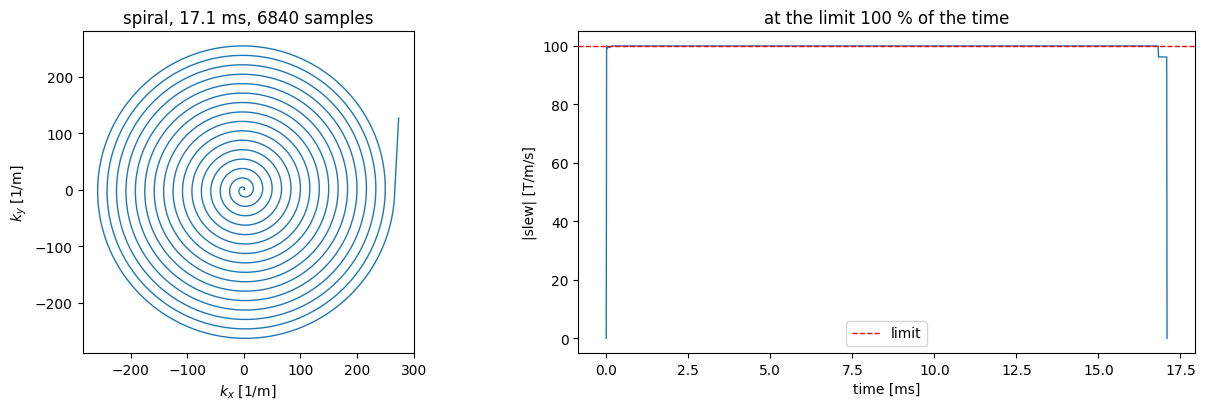

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.2))
kx, ky = readout.trajectory(0)
axes[0].plot(kx, ky, lw=1)
axes[0].set_title(f'spiral, {readout.readout_duration_us / 1e3:.1f} ms, '
                  f'{readout.n_samples} samples')
axes[0].set_xlabel('$k_x$ [1/m]'); axes[0].set_ylabel('$k_y$ [1/m]'); axes[0].set_aspect('equal')

gx, gy = np.asarray(readout.gx.waveform), np.asarray(readout.gy.waveform)
slew = np.hypot(np.diff(gx), np.diff(gy)) / system.grad_raster.dt
limits = system.limits(REGIME)
axes[1].plot(np.arange(len(slew)) * system.grad_raster.dt * 1e3, slew / system.gamma, lw=1)
axes[1].axhline(limits.max_slew / system.gamma, ls='--', c='r', lw=1, label='limit')
axes[1].set_xlabel('time [ms]'); axes[1].set_ylabel('|slew| [T/m/s]')
axes[1].set_title(f'at the limit {slew.mean() / limits.max_slew * 100:.0f} % of the time')
axes[1].legend()
figure.tight_layout()
plt.show()

## 6. Write the files

Both `.seq` files, and one sidecar each. The spiral's sidecar carries its **trajectory at ADC sample
times** — not recoverable from the `.seq` in a form a reconstruction can use — checked here against
pypulseq's own k-space calculation. The field map's carries its echo times and line order.

In [9]:
OUT = Path('seq')
OUT.mkdir(exist_ok=True)
for stale in OUT.glob('*'):
    stale.unlink()

# ---- the spiral -------------------------------------------------------------------------------
dti_stem = f'spiral_dti_{MATRIX}_fov{FOV_MM:.0f}_b{B_VALUE:.0f}_d{len(directions)}'
written = dti.write(OUT / f'{dti_stem}.seq')

kx0, ky0 = readout.trajectory(0)
t_design = (np.arange(len(kx0)) + 1) * system.grad_raster.dt      # k after n rasters
t_adc = float(readout.adc.delay) + (np.arange(readout.n_samples) + 0.5) * float(readout.adc.dwell)
trajectory = np.stack([np.stack([np.interp(t_adc, t_design, axis_k)
                                 for axis_k in readout.trajectory(i)])
                       for i in range(N_INTERLEAVES)])
disagreement = float(np.abs(trajectory[0] - k_dti['k_adc'][:2, :readout.n_samples]).max())
assert disagreement < 1.0, f'sidecar disagrees with the sequence by {disagreement:.2f} 1/m'

np.savez_compressed(
    OUT / f'{dti_stem}.traj.npz',
    k_per_m=trajectory.astype(np.float32),          # (interleaf, xy, ADC sample), 1/m
    t_adc_s=t_adc.astype(np.float64),               # from the readout block start
    # Where k=0 sits in t_adc_s.  For a spiral that is the ADC delay, because sampling *starts* at
    # the origin -- but recording it is what lets one reconstruction serve a readout whose echo
    # falls mid-train, instead of inferring the echo from the first sample.
    t_echo_s=np.float64(readout.time_to_echo),
    fov_m=np.float64(FOV_MM / 1e3), matrix=np.int64(MATRIX),
    n_interleaves=np.int64(N_INTERLEAVES),
    dwell_s=np.float64(readout.adc.dwell), n_samples=np.int64(readout.n_samples),
    te_s=np.float64(te), tr_s=np.float64(tr),
    directions=np.asarray(directions, dtype=np.float32),
    b_values=np.asarray([0.0, B_VALUE], dtype=np.float64),
    achieved_b_values=np.asarray([0.0, weighted.achieved_b_s_per_mm2()], dtype=np.float64),
)
print(f'{written.path.name}')
print(f'  {written.n_blocks} blocks, {written.duration_s / 60:.2f} min, '
      f'{written.path.stat().st_size / 1e6:.2f} MB, sha256 {written.sha256[:16]}...')
print(f'  trajectory {trajectory.shape}, agrees with the sequence to {disagreement:.3f} 1/m')

# ---- the field map ----------------------------------------------------------------------------
b0_stem = f'b0map_{B0_MATRIX}_fov{FOV_MM:.0f}'
b0_written = b0.write(OUT / f'{b0_stem}.seq')
np.savez_compressed(
    OUT / f'{b0_stem}.meta.npz',
    te_s=np.asarray(B0_TE_S, dtype=np.float64),
    delta_te_s=np.float64(B0_DTE),
    fov_m=np.float64(FOV_MM / 1e3), matrix=np.int64(B0_MATRIX),
    lines=np.asarray(b0_geometry.pe_lines, dtype=np.int64),
    dummies=np.int64(B0_DUMMIES),
    polarity=np.asarray([1, 1], dtype=np.int64),       # flyback, so both echoes read the same way
    centre_line=np.int64(b0_geometry.kspace_center_line),
    n_samples=np.int64(b0_line.adc.num_samples),
)
print(f'{b0_written.path.name}')
print(f'  {b0_written.n_blocks} blocks, {b0_written.duration_s:.1f} s, '
      f'sha256 {b0_written.sha256[:16]}...')
print()
print('Play the field map first, then the DTI.  Notebook 2 reconstructs both.')

spiral_dti_128_fov240_b1000_d18.seq
  1211 blocks, 2.50 min, 0.33 MB, sha256 3aab6343352bac51...
  trajectory (4, 2, 6840), agrees with the sequence to 0.030 1/m
b0map_128_fov240.seq
  1323 blocks, 4.7 s, sha256 d87ecf1aa23b9426...

Play the field map first, then the DTI.  Notebook 2 reconstructs both.


In [10]:
# Read both back and confirm the file is what was compiled.
for path, compiled in ((written.path, dti), (b0_written.path, b0)):
    again = pp.Sequence(system=system.limits(REGIME))
    again.read(str(path))
    assert len(again.block_events) == compiled.n_blocks
    print(f'{path.name:44} {len(again.block_events):6} blocks, '
          f'{again.duration()[0]:8.2f} s  round-trips')

spiral_dti_128_fov240_b1000_d18.seq            1211 blocks,   150.06 s  round-trips
b0map_128_fov240.seq                           1323 blocks,     4.68 s  round-trips


## Before you scan

- **Field map first.** The DTI reconstruction needs it, and it costs four seconds.
- **Check PNS against your own `.asc`**, not the synthetic model. Section 4 does this when
  `SEQCRAFT_ASC_DIR` points at the directory holding it; the file is never copied into this repo.
- **The slice position is shared** between the two sequences. If you move one, move both, or the field
  map describes a different slice than the one it is correcting.
- **A spiral needs its gradient delay measured** on the system it runs on. A microsecond or two shifts
  the trajectory against the data and shows up as a ring or a shading that no field map explains.